# Solving the Krusell-Smith (1998) Model in Julia

This notebook solves the Krusell-Smith (1998) model using value function iteration (VFI). The notebook is structured as follows:
1. Model setup (household, firm, equilibrium approximation).
2. Numerical algorithm description.
3. Julia implementation (VFI + simulation + law-of-motion update).

## 1) Original Model and Equilibrium

### HH problem

Individual state is $s=(k,e,z,\Phi)$, where $k$ is assets, $e\in\{0,1\}$ is employment, $z\in\{z_b,z_g\}$ is aggregate productivity, and $\Phi$ is the distribution of wealth and employment across agents.

Given prices $r(z,\Phi)$ and $w(z,\Phi)$, and law of motion for the distribution $\Phi'$, the Bellman equation is
$$
V(k,e,z,\Phi)=\max_{k'\in\mathcal K}\left\{u(c)+\beta\,\mathbb E\left[V(k',e',z',\Phi')\mid e,z\right]\right\} \quad\text{s.t.}\quad \\

c + k' = (1+r(z,\Phi))k + w(z,\Phi)e \\
k'\ge k_{min} \\
\Phi' = \mathcal{H}(\Phi,z,z')
$$

However, the distribution $\Phi$ is infinite-dimensional, so we cannot solve this model numerically. 

Instead, we follow Krusell-Smith and approximate the distribution with a finite set of moments, which here we denote $K$ (aggregate capital). 

## 2) Model with Krusell-Smith Approximation

### HH problem
Individual state is $s=(k,e,z,K)$, where $k$ is assets, $e\in\{0,1\}$ is employment, $z\in\{z_b,z_g\}$ is aggregate productivity, and $K$ is aggregate capital.
Given prices and an aggregate forecasting rule, the Bellman equation is
$$
V(k,e,z,K)=\max_{k'\in\mathcal K}\left\{u(c)+\beta\,\mathbb E\left[V(k',e',z',K')\mid e,z\right]\right\} \quad\text{s.t.}\quad \\

c + k' = (1+r(z,K,L))k + w(z,K,L)e \\
k'\ge k_{min} \\
K' = \mathcal{H}(K,z)
$$


### Firms problem
We assume a representative firm with production function:
$$
Y = zK^\alpha N^{1-\alpha},
$$
and competitive factor prices are
$$
r = \alpha z (K/N)^{\alpha-1}-\delta,\qquad
w = (1-\alpha)z(K/N)^\alpha.
$$

### Equilibrium definition
A recursive equilibrium is a collection
$$
\{V,\,g,\mathcal{H},\,r,\,w,\,\Phi\},
$$

such that:
1. Given $(r(z,K,L),w(z,K,L))$ and perceived law of motion $\mathcal{H}$, value function $V$ and policy function $g$ solve the household problem.
2. Given $z$ and $r(z,K,L), w(z,K,L)$, firm maximizes profits, in particular:
$$
r(z,K,L) = \alpha z (K/N)^{\alpha-1}-\delta,\qquad
w(z,K,L) = (1-\alpha)z(K/N)^\alpha.
$$
3. Given $g$ and shock transitions, we can obtain the actual law of motion for aggregate capital:
    $$
    K' = \mathcal{G}(K,z)
    $$
    The actual law of motion $\mathcal{G}$ is consistent with the perceived law of motion $\mathcal{H}$
4. Market clearing:
$$
K = \int k\,d\Phi(k,e,z,K) \\
N = \int e\,d\Phi(k,e,z,K)
$$

Krusell-Smith approximation specifies a particular functional form for the perceived law of motion $\mathcal{H}$, which is log-linear:
$$
\log K' = a_z + b_z \log K
$$

## 3) General Numerical Algorithm (Inner/Outer Iteration)

We use a nested iteration algorithm.

### Inner loop: solve HH problem
Given coefficients $(a_z,b_z)$, we map $K$ to predicted $K'$ and solve HH problem:
$$
V(k,e,z,K)=\max_{k'\in\mathcal K}\left\{u(c)+\beta\,\mathbb E\left[V(k',e',z',K')\mid e,z\right]\right\} \quad\text{s.t.}\quad \\

c + k' = (1+r(z,K,L))k + w(z,K,L)e \\
k'\ge k_{min} \\
\log K' = a_z + b_z \log K
$$

At each state $(k,e,z,K)$ we search over $k'\in\mathcal K$ and compute expected continuation value using transition probabilities for $(z,e)\to(z',e')$.
We iterate until value function converged:
$$
\|V_{new}-V\|_\infty < \varepsilon_V.
$$

### Outer loop: update aggregate law of motion
With the policy function $g(k,e,z,K)$ solved from the inner loop, we:
1. Simulate many households and periods.
2. Construct time series data $\{K_t,z_t\}$.
3. Run state-by-state regressions
$$
\log K_{t+1}=a_z+b_z\log K_t+\epsilon_{t+1},\qquad z\in\{b,g\}.
$$
4. Update perceived coefficients with damping
$$
\theta^{new}=\lambda\theta^{old}+(1-\lambda)\hat\theta,\quad \theta=(a_b,b_b,a_g,b_g).
$$
5. Repeat until stopping criterion is met (in this notebook: both $R^2$ exceed a threshold).


---

# Code Implementation in Julia

## 1) Calibration

### 1) Structural parameters
We use:
- Discount factor: $\beta = 0.99$
- Risk aversion: $\sigma = 1$ (log utility)
- Capital share: $\alpha = 0.36$
- Depreciation: $\delta = 0.025$
- Ad hoc borrowing constraint: $k_{min} = 0$
- Aggregate shock values: $z_b=0.99$, $z_g=1.01$
- Hours of labor supply when employed: $\tilde{l}= 0.3271$

We have these following calibration targets:
- Unemployment rates: $u_b=0.10$, $u_g=0.04$
- Average duration of both good and bad times is eight quarters
- Average duration of unemployment is 1.5 quarters in good times and 2.5 quarters in bad times.

### 2) Aggregate productivity shocks
- Aggregate productivity is two-state:
    $$
    z_t \in \{z_b, z_g\}, \quad z_b=0.99,\; z_g=1.01.
    $$

    The transition matrix is:
    $$
    \Pi_z = \begin{bmatrix} \pi_{bb} & \pi_{bg} \\
    \pi_{gb} & \pi_{gg} \end{bmatrix}
    $$


- Aggregate unemployment rates:
  
    We assume different unemployment rates in the two aggregate states:
    $$
    u_b=0.10,\quad u_g=0.04.
    $$
    In the bad state, 10% of agents are unemployed, while in the good state only 4% are unemployed.

- Effective aggregate labor in each state:
    $$
    L_b=\tilde{l}(1-u_b) = 0.2944, \\
    L_g=\tilde{l}(1-u_g) = 0.3142.
    $$

### 3) Calibrating the aggregate transition matrix.

- First, calibrate the transition matrix for the aggregate shock $z$.

    Average duration of each aggregate state is 8 quarters, we know that:

    The duration of state $s$ can be computed:
    $$
    \text{Duration}_s = \sum_{t=1}^\infty t \cdot (1-\pi_{ss}) \pi_{ss}^{t-1} = \frac{1}{1-\pi_{ss}}
    $$
    Thus
    $$
    \pi_{bb} = \pi_{gg} = 1 - \frac{1}{8} = 0.875, \qquad
    \pi_{bg} = \pi_{gb} = 0.125.
    $$

### 4) Calibrating the joint transition matrix for $(z,e)$.

Then, we calibrate the joint transition matrix for $(z,e)$
  
We assume the individual shock $e$ is correlated with the aggregate shock $z$, thus we need to specify the joint transition matrix for $(z,e)$.
    
Addtionally, we assume that given $z$, transition of individual employment status $e$ is independent cross agents:

Thus, we have $\forall s,s'\in\{b,g\}$:
$$
\pi_{ss'00} +  \pi_{ss'01} = \pi_{ss'10} + \pi_{ss'11} = \pi_{ss'}
$$
and
$$
u_s \frac{\pi_{ss'00}}{\pi_{ss'}} + (1-u_s)\frac{\pi_{ss'10}}{\pi_{ss'}} = u_{s'}
$$

From transition matrix of $z$, we have:
$$
\pi_{bb00} + \pi_{bb01} = 0.875, \\
\pi_{bb10} + \pi_{bb11} = 0.875, \\
\pi_{bg00} + \pi_{bg01} = 0.125, \\
\pi_{bg10} + \pi_{bg11} = 0.125, \\
\pi_{gb00} + \pi_{gb01} = 0.125, \\
\pi_{gb10} + \pi_{gb11} = 0.125, \\
\pi_{gg00} + \pi_{gg01} = 0.875, \\
\pi_{gg10} + \pi_{gg11} = 0.875.
$$

We already know that average unemployment duration is 1.5 quarters in good times and 2.5 quarters in bad times, thus we have:
$$
\pi_{bb00} = 1 - \frac{1}{2.5} = 0.6, \\
\pi_{gg00} = 1 - \frac{1}{1.5} = 1/3.
$$
Implies
$$
\pi_{bb01} = 0.875 - \pi_{bb00} = 0.275, \\
\pi_{gg01} = 0.875 - \pi_{gg00} = 0.542.
$$

Then we impose additional restrictions to solve for the rest of the transition probabilities:
$$
\frac{\pi_{gb00}}{\pi_{bb00}} = 1.25 \frac{\pi_{gb}}{\pi_{bb}} \Rightarrow \\
\pi_{gb00} = 1.25 \cdot \frac{0.125}{0.875} \cdot 0.6 = 0.107, \\
\pi_{gb01} = 0.125 - \pi_{gb00} = 0.018,
$$

Another additional restriction:
$$
\frac{\pi_{bg00}}{\pi_{gg00}} = 0.75 \frac{\pi_{bg}}{\pi_{gg}} \Rightarrow \quad \\
\pi_{bg00} = 0.75 \cdot \frac{0.125}{0.875} \cdot \frac{1}{3} = 0.036, \\
\pi_{bg01} = 0.125 - \pi_{bg00} = 0.089, \\
$$

Remaining probabilities have to be such that unemployment is always constant:
$$
u_s \frac{\pi_{ss'00}}{\pi_{ss'}} + (1-u_s)\frac{\pi_{ss'10}}{\pi_{ss'}} = u_{s'}
$$

Thus, we have:
$$
u_g \frac{\pi_{gg00}}{\pi_{gg}} + (1-u_g)\frac{\pi_{gg10}}{\pi_{gg}} = u_g \\
u_g \frac{\pi_{gb00}}{\pi_{gb}} + (1-u_g)\frac{\pi_{gb10}}{\pi_{gb}} = u_b \\
u_b \frac{\pi_{bb00}}{\pi_{bb}} + (1-u_b)\frac{\pi_{bb10}}{\pi_{bb}} = u_b \\
u_b \frac{\pi_{bg00}}{\pi_{bg}} + (1-u_b)\frac{\pi_{bg10}}{\pi_{bg}} = u_g
$$

Plug in parameters we know and solve for the rest of the transition probabilities:
$$
0.04 \cdot \frac{1/3}{0.875} + 0.96 \cdot \frac{\pi_{gg10}}{0.875} = 0.04 \quad \Rightarrow \quad \pi_{gg10} = 0.022 \quad \Rightarrow \quad \pi_{gg11} = 0.875 - 0.022 = 0.853 \\
0.04 \cdot \frac{0.107}{0.125} + 0.96 \cdot \frac{\pi_{gb10}}{0.125} = 0.10 \quad \Rightarrow \quad \pi_{gb10} = 0.008 \quad \Rightarrow \quad \pi_{gb11} = 0.125 - 0.008 = 0.117 \\
0.10 \cdot \frac{0.6}{0.875} + 0.90 \cdot \frac{\pi_{bb10}}{0.875} = 0.10 \quad \Rightarrow \quad \pi_{bb10} = 0.030 \quad \Rightarrow \quad \pi_{bb11} = 0.875 - 0.030 = 0.845 \\
0.10 \cdot \frac{0.036}{0.125} + 0.90 \cdot \frac{\pi_{bg10}}{0.125} = 0.04 \quad \Rightarrow \quad \pi_{bg10} = 0.002 \quad \Rightarrow \quad \pi_{bg11} = 0.125 - 0.002 = 0.123
$$

Thus, the joint transition matrix for $(z,e)$ is:
$$
P=
\begin{bmatrix}
\pi_{bb00} & \pi_{bb01} & \pi_{bg00} & \pi_{bg01}\\
\pi_{bb10} & \pi_{bb11} & \pi_{bg10} & \pi_{bg11}\\
\pi_{gb00} & \pi_{gb01} & \pi_{gg00} & \pi_{gg01}\\
\pi_{gb10} & \pi_{gb11} & \pi_{gg10} & \pi_{gg11}
\end{bmatrix}.
$$

Substituting in the calibrated values gives

$$
P \approx
\begin{bmatrix}
0.600 & 0.275 & 0.036 & 0.089\\
0.031 & 0.844 & 0.002 & 0.123\\
0.107 & 0.018 & 0.333 & 0.542\\
0.009 & 0.116 & 0.023 & 0.852
\end{bmatrix}.
$$





## 4) Julia Implementation (Appended)

The cells below are appended and keep your earlier markdown sections unchanged.

### Step 1: Packages and Calibrated Parameters

This cell imports packages and defines calibrated parameters.

Perceived aggregate law:
$$\log K_{t+1}=a_z+b_z\log K_t,\quad z\in\{b,g\}.$$

In [14]:
using Random, Statistics, LinearAlgebra, Printf, Plots

In [15]:
Base.@kwdef mutable struct KSParams
    beta::Float64 = 0.99
    sigma::Float64 = 1.0
    alpha::Float64 = 0.36
    delta::Float64 = 0.025
    l_tilde::Float64 = 0.3271

    z_vals::Vector{Float64} = [0.99, 1.01]   # [bad, good]
    u_rate::Vector{Float64} = [0.10, 0.04]
    N_vals::Vector{Float64} = [0.2944, 0.3142]

    Pz::Matrix{Float64} = [0.875 0.125;
                           0.125 0.875]

    
    # state order: 1=(b,u), 2=(b,e), 3=(g,u), 4=(g,e)
    Pze::Matrix{Float64} = [0.600 0.275 0.036 0.089;
                            0.031 0.844 0.002 0.123;
                            0.107 0.018 0.333 0.542;
                            0.009 0.116 0.023 0.852]
    
    # state order in notebook:
    # 1=(b,u), 2=(b,e), 3=(g,u), 4=(g,e)
    #=
    Pze::Matrix{Float64} = [
        0.600000 0.275000 0.060000 0.065000;
        0.031000 0.845000 0.007000 0.117000;
        0.107000 0.018000 0.333333 0.541667;
        0.009000 0.116000 0.014000 0.861000
    ]
    =#

    k_min::Float64 = 0.0
    k_max::Float64 = 30
    nk::Int = 300
    K_min::Float64 = 1.0
    K_max::Float64 = 30
    nK::Int = 60

    N_agents::Int = 3000
    T_sim::Int = 6000
    burn_in::Int = 1000
end

@inline state_index(ie::Int, iz::Int) = (iz - 1) * 2 + ie

util(c, sigma) = c <= 0 ? -1.0e12 : (sigma == 1.0 ? log(c) : (c^(1.0 - sigma) - 1.0) / (1.0 - sigma))

function make_grids(par::KSParams)
    kgrid = collect(range(par.k_min, par.k_max, length = par.nk))
    Kgrid = collect(range(par.K_min, par.K_max, length = par.nK))
    return kgrid, Kgrid
end

function prices(par::KSParams, K::Float64, iz::Int)
    z = par.z_vals[iz]
    N = par.N_vals[iz]
    Kn = K / max(N, 1.0e-12)
    r = par.alpha * z * Kn^(par.alpha - 1.0) - par.delta
    w = (1.0 - par.alpha) * z * Kn^par.alpha
    return r, w
end

function nearest_index(grid::Vector{Float64}, x::Float64)
    j = searchsortedfirst(grid, x)
    if j <= 1
        return 1
    elseif j > length(grid)
        return length(grid)
    else
        return abs(grid[j] - x) < abs(grid[j - 1] - x) ? j : j - 1
    end
end

function linear_interp_weights(grid::Vector{Float64}, x::Float64)
    j = searchsortedfirst(grid, x)
    if j <= 1
        return 1, 1, 0.0
    elseif j > length(grid)
        n = length(grid)
        return n, n, 0.0
    else
        lo = j - 1
        hi = j
        w = (x - grid[lo]) / (grid[hi] - grid[lo])
        return lo, hi, clamp(w, 0.0, 1.0)
    end
end

@inline function cubic_spline_interp_K(V, ikp::Int, iep::Int, izp::Int, iKlo::Int, iKhi::Int, wK::Float64)
    nK = size(V, 2)
    if iKlo == iKhi || iKlo <= 1 || iKhi >= nK
        return (1.0 - wK) * V[ikp, iKlo, iep, izp] + wK * V[ikp, iKhi, iep, izp]
    end

    i0 = iKlo - 1
    i1 = iKlo
    i2 = iKhi
    i3 = iKhi + 1

    y0 = V[ikp, i0, iep, izp]
    y1 = V[ikp, i1, iep, izp]
    y2 = V[ikp, i2, iep, izp]
    y3 = V[ikp, i3, iep, izp]

    t = wK
    a0 = -0.5 * y0 + 1.5 * y1 - 1.5 * y2 + 0.5 * y3
    a1 = y0 - 2.5 * y1 + 2.0 * y2 - 0.5 * y3
    a2 = -0.5 * y0 + 0.5 * y2
    a3 = y1

    v = ((a0 * t + a1) * t + a2) * t + a3
    lo = min(y1, y2)
    hi = max(y1, y2)
    return clamp(v, lo, hi)
end

@inline function continuation_value(V, kgrid, kp::Float64, iep::Int, izp::Int, iKlo::Int, iKhi::Int, wK::Float64)
    iklo, ikhi, wk = linear_interp_weights(kgrid, kp)
    vlo = cubic_spline_interp_K(V, iklo, iep, izp, iKlo, iKhi, wK)
    vhi = cubic_spline_interp_K(V, ikhi, iep, izp, iKlo, iKhi, wK)
    return (1.0 - wk) * vlo + wk * vhi
end

@inline function bellman_rhs(par::KSParams, V, kgrid, cash::Float64, kp::Float64, cur_state::Int, iKlo::Int, iKhi::Int, wK::Float64)
    u = util(cash - kp, par.sigma)
    if u <= -1.0e11
        return -1.0e18
    end

    ev = 0.0
    @inbounds for izp in 1:2
        for iep in 1:2
            nxt_state = state_index(iep, izp)
            p = par.Pze[cur_state, nxt_state]
            ev += p * continuation_value(V, kgrid, kp, iep, izp, iKlo, iKhi, wK)
        end
    end
    return u + par.beta * ev
end

function continuous_argmax(par::KSParams, V, kgrid, cash::Float64, cur_state::Int, iKlo::Int, iKhi::Int, wK::Float64;
    n_coarse::Int = 25, tol::Float64 = 1e-4, max_iter::Int = 80)

    lower = par.k_min
    upper = min(par.k_max, cash - 1.0e-10)
    if upper <= lower + 1.0e-10
        kp = lower
        return kp, bellman_rhs(par, V, kgrid, cash, kp, cur_state, iKlo, iKhi, wK)
    end

    xs = collect(range(lower, upper, length = max(n_coarse, 3)))
    vals = similar(xs)
    for j in eachindex(xs)
        vals[j] = bellman_rhs(par, V, kgrid, cash, xs[j], cur_state, iKlo, iKhi, wK)
    end

    best_j = argmax(vals)
    best_x = xs[best_j]
    best_v = vals[best_j]

    left = best_j == 1 ? xs[1] : xs[best_j - 1]
    right = best_j == length(xs) ? xs[end] : xs[best_j + 1]
    if right <= left + tol
        return best_x, best_v
    end

    phi = (sqrt(5.0) - 1.0) / 2.0
    c = right - phi * (right - left)
    d = left + phi * (right - left)
    fc = bellman_rhs(par, V, kgrid, cash, c, cur_state, iKlo, iKhi, wK)
    fd = bellman_rhs(par, V, kgrid, cash, d, cur_state, iKlo, iKhi, wK)

    for _ in 1:max_iter
        if (right - left) <= tol * max(1.0, abs(c) + abs(d))
            break
        end
        if fc > fd
            right = d
            d = c
            fd = fc
            c = right - phi * (right - left)
            fc = bellman_rhs(par, V, kgrid, cash, c, cur_state, iKlo, iKhi, wK)
        else
            left = c
            c = d
            fc = fd
            d = left + phi * (right - left)
            fd = bellman_rhs(par, V, kgrid, cash, d, cur_state, iKlo, iKhi, wK)
        end
    end

    if fc > fd
        cand_x, cand_v = c, fc
    else
        cand_x, cand_v = d, fd
    end

    return cand_v > best_v ? (cand_x, cand_v) : (best_x, best_v)
end

par = KSParams()
@assert all(abs.(sum(par.Pz, dims = 2) .- 1.0) .< 1e-12)
@assert all(abs.(sum(par.Pze, dims = 2) .- 1.0) .< 1e-12)
println("Step 1 ready.")

Step 1 ready.


### Step 2: Solve HH problem with VFI and Howard PFI

HH problem is:
$$
V(k,e,z,K)=\max_{k'\in\mathcal K}\left\{u(c)+\beta\,\mathbb E\left[V(k',e',z',K')\mid e,z\right]\right\} \quad\text{s.t.}\quad \\

c + k' = (1+r(z,K,L))k + w(z,K,L)e \\
k'\ge k_{min} \\
\log K' = a_z + b_z \log K
$$

First, we solve the HH problem with VFI.

In [16]:
function solve_household_vfi(par::KSParams, kgrid, Kgrid, coeff; max_iter = 2000, tol = 1e-6, opt_tol = 1e-4)
    nk, nK = length(kgrid), length(Kgrid)
    V = zeros(nk, nK, 2, 2)
    Vnew = similar(V)
    pol = zeros(nk, nK, 2, 2)

    for it in 1:max_iter
        diff = 0.0
        for iz in 1:2
            for iK in 1:nK
                K = Kgrid[iK]
                r, w = prices(par, K, iz)
                Knext = exp(coeff[iz, 1] + coeff[iz, 2] * log(K))
                iKlo, iKhi, wK = linear_interp_weights(Kgrid, Knext)

                for ie in 1:2
                    labor_income = ie == 2 ? w * par.l_tilde : 0.0
                    cur_state = state_index(ie, iz)

                    for ik in 1:nk
                        cash = (1.0 + r) * kgrid[ik] + labor_income
                        best_kp, best_v = continuous_argmax(par, V, kgrid, cash, cur_state, iKlo, iKhi, wK; tol = opt_tol)
                        Vnew[ik, iK, ie, iz] = best_v
                        pol[ik, iK, ie, iz] = best_kp
                        diff = max(diff, abs(best_v - V[ik, iK, ie, iz]))
                    end
                end
            end
        end

        V, Vnew = Vnew, V
        if it % 50 == 0
            @printf("  VFI iter %d, diff = %.3e\n", it, diff)
        end
        if diff < tol
            @printf("  VFI converged at iter %d, diff = %.3e\n", it, diff)
            return V, pol
        end
    end

    @warn "VFI reached max_iter without full convergence"
    return V, pol
end

solve_household_vfi (generic function with 1 method)

Then we solve HH problem with Howard policy function iteration, which should be much faster.

### Algorithm: Howard Policy Function Iteration (PFI)

We solve
$$
V(k,e,z,K)=\max_{k'\in\mathcal K}\left\{u(c)+\beta \mathbb E\left[V(k',e',z',K')\mid e,z\right]\right\}, \quad\text{s.t.}\quad \\
c + k' = (1+r(z,K,L))k + w(z,K,L)e \\
k'\ge k_{min} \\
\log K' = a_z + b_z \log K.
$$

1. **Initialize**
   - Set an initial policy $g_0(k,e,z,K)$.
   - Set an initial value function $V_0(k,e,z,K)$.

2. **Policy Evaluation (fixed policy)**
   - Keep $g_n$ fixed.
   - For each state $(k,e,z,K)$, compute the implied choice $k'=g_n(k,e,z,K)$ and update
   $$
   V_{m+1}(k,e,z,K)=u(c)+\beta\mathbb E\!\left[V_m(k',e',z',K')\mid e,z\right].
   $$
   - Iterate until:
   $$
   \|V_{m+1}-V_m\|_\infty < \varepsilon_V
   $$
   Then set $V^{g_n} = V_m$.


3. **Policy Improvement**
   - After getting the evaluated value function $V^{g_n}$, we can then optimize at each state:
   $$
   g_{n+1}(k,e,z,K) =\arg\max_{k'\in\mathcal K} \left\{ u(c)+\beta\mathbb E\!\left[V^{g_n}(k',e',z',K')\mid e,z\right] \right\} \quad\text{s.t.}\quad \\
   c + k' = (1+r(z,K,L))k + w(z,K,L)e \\
   k'\ge k_{min} \\
   \log K' = a_z + b_z \log K.
   $$
   - Record how many grid points changed in this policy improvement step, keep iterate until:
   $$
   n\_change = 0.
   $$
   n_change counts how many grid points have different policy choices between $g_n$ and $g_{n+1}$.

4. **Convergence Check**
   - If $n\_change = 0$, the policy is stable on the grid (policy convergence).
   - For stricter stopping, also require the evaluation residual to be small.
   - Otherwise set $n\leftarrow n+1$ and repeat Steps 2?.

Howard PFI is faster than plain VFI because maximization is done only in the improvement step, while evaluation steps are cheap Bellman updates under a fixed policy.


In [17]:
function solve_household_pfi(par::KSParams, kgrid, Kgrid, coeff;
    max_policy_iter = 300, eval_iter = 25, tol = 1e-6, final_eval_iter = 200,
    opt_tol = 1e-4, policy_tol = 1e-4, improve_tol = 1e-8)

    nk, nK = length(kgrid), length(Kgrid)
    V = zeros(nk, nK, 2, 2)
    Vnew = similar(V)

    pol = Array{Float64}(undef, nk, nK, 2, 2)
    pol_new = similar(pol)

    for iz in 1:2, iK in 1:nK, ie in 1:2, ik in 1:nk
        pol[ik, iK, ie, iz] = kgrid[ik]
    end

    for pit in 1:max_policy_iter
        V_prev_pit = copy(V)
        diff_eval = Inf

        # Policy evaluation for a fixed continuous policy rule
        for _ in 1:eval_iter
            diff_eval = 0.0
            for iz in 1:2
                for iK in 1:nK
                    K = Kgrid[iK]
                    r, w = prices(par, K, iz)
                    Knext = exp(coeff[iz, 1] + coeff[iz, 2] * log(K))
                    iKlo, iKhi, wK = linear_interp_weights(Kgrid, Knext)

                    for ie in 1:2
                        labor_income = ie == 2 ? w * par.l_tilde : 0.0
                        cur_state = state_index(ie, iz)

                        for ik in 1:nk
                            kp = pol[ik, iK, ie, iz]
                            Vnew[ik, iK, ie, iz] = bellman_rhs(
                                par, V, kgrid,
                                (1.0 + r) * kgrid[ik] + labor_income,
                                kp, cur_state, iKlo, iKhi, wK
                            )
                            diff_eval = max(diff_eval, abs(Vnew[ik, iK, ie, iz] - V[ik, iK, ie, iz]))
                        end
                    end
                end
            end

            V, Vnew = Vnew, V
            if diff_eval < tol
                break
            end
        end

        # Policy improvement with value-improvement filter
        n_change = 0
        for iz in 1:2
            for iK in 1:nK
                K = Kgrid[iK]
                r, w = prices(par, K, iz)
                Knext = exp(coeff[iz, 1] + coeff[iz, 2] * log(K))
                iKlo, iKhi, wK = linear_interp_weights(Kgrid, Knext)

                for ie in 1:2
                    labor_income = ie == 2 ? w * par.l_tilde : 0.0
                    cur_state = state_index(ie, iz)

                    for ik in 1:nk
                        cash = (1.0 + r) * kgrid[ik] + labor_income
                        old_kp = pol[ik, iK, ie, iz]
                        old_v = bellman_rhs(par, V, kgrid, cash, old_kp, cur_state, iKlo, iKhi, wK)

                        new_kp, new_v = continuous_argmax(
                            par, V, kgrid, cash, cur_state, iKlo, iKhi, wK;
                            tol = opt_tol
                        )

                        # Only switch policy if the value improvement is meaningful
                        if (new_v - old_v > improve_tol) && (abs(new_kp - old_kp) > policy_tol)
                            pol_new[ik, iK, ie, iz] = new_kp
                            n_change += 1
                        else
                            pol_new[ik, iK, ie, iz] = old_kp
                        end
                    end
                end
            end
        end

        pol, pol_new = pol_new, pol
        diff_V = maximum(abs.(V .- V_prev_pit))

        if pit % 10 == 0
            @printf("  PFI iter %d, eval diff = %.3e, dV = %.3e, n_change = %d\n",
                    pit, diff_eval, diff_V, n_change)
        end

        # Main stopping rule: policy convergence
        if n_change == 0
            # Optional short final evaluation pass, only for diagnostics / refinement
            for fe in 1:final_eval_iter
                diff_eval = 0.0
                for iz in 1:2
                    for iK in 1:nK
                        K = Kgrid[iK]
                        r, w = prices(par, K, iz)
                        Knext = exp(coeff[iz, 1] + coeff[iz, 2] * log(K))
                        iKlo, iKhi, wK = linear_interp_weights(Kgrid, Knext)

                        for ie in 1:2
                            labor_income = ie == 2 ? w * par.l_tilde : 0.0
                            cur_state = state_index(ie, iz)

                            for ik in 1:nk
                                kp = pol[ik, iK, ie, iz]
                                Vnew[ik, iK, ie, iz] = bellman_rhs(
                                    par, V, kgrid,
                                    (1.0 + r) * kgrid[ik] + labor_income,
                                    kp, cur_state, iKlo, iKhi, wK
                                )
                                diff_eval = max(diff_eval, abs(Vnew[ik, iK, ie, iz] - V[ik, iK, ie, iz]))
                            end
                        end
                    end
                end

                V, Vnew = Vnew, V

                # If fixed-policy value also converges quickly, report it
                if diff_eval < tol
                    @printf("  PFI converged at iter %d, eval diff = %.3e, dV = %.3e\n",
                            pit, diff_eval, diff_V)
                    return V, pol
                end
            end

            # More KS-style stopping: policy is stable, so stop even if value not fully converged
            @printf("  PFI policy converged at iter %d (n_change = 0). Final eval diff = %.3e\n",
                    pit, diff_eval)
            return V, pol
        end
    end

    @warn "PFI reached max_policy_iter without full policy convergence"
    return V, pol
end

println("Step 2 ready.")


Step 2 ready.


We compare the result obtained from VFI and Howard PFI, they should be very close. 

And we also compare the computational time. Howard PFI is much faster than VFI, especially when the state space is large.

In [18]:
#=
# 1) grids + coefficients
kgrid, Kgrid = make_grids(par)
coeff = @isdefined(res) ? res.coeff : [0.05 0.95; 0.05 0.95]

# 2) solve HH with both methods (run once each, keep results and time)

t_vfi = @elapsed begin
    V_vfi, pol_vfi = solve_household_vfi(par, kgrid, Kgrid, coeff; max_iter=2000, tol=1e-5)
end

t_pfi = @elapsed begin
    V_pfi, pol_pfi = solve_household_pfi(par, kgrid, Kgrid, coeff; max_policy_iter=2000, eval_iter=25, tol=1e-5)
end

@printf("\nSpeed comparison (seconds): VFI = %.3f, PFI(Howard) = %.3f\n", t_vfi, t_pfi)

# 3) fix one K
K_fixed = 20.0
iK = nearest_index(Kgrid, K_fixed)

# 4) plot k'(k) for each (z,e)
state_titles = Dict(
    (1,1) => "z=bad, e=unemp",
    (1,2) => "z=bad, e=emp",
    (2,1) => "z=good, e=unemp",
    (2,2) => "z=good, e=emp"
)

p = plot(layout=(2,2), size=(1000,700), legend=:topleft)

panel = 1
for iz in 1:2
    for ie in 1:2
        kp_vfi = [kgrid[pol_vfi[ik, iK, ie, iz]] for ik in 1:length(kgrid)]
        kp_pfi = [kgrid[pol_pfi[ik, iK, ie, iz]] for ik in 1:length(kgrid)]

        plot!(p[panel], kgrid, kp_vfi, lw=2, label="VFI")
        plot!(p[panel], kgrid, kp_pfi, lw=2, ls=:dash, label="PFI")
        plot!(p[panel], kgrid, kgrid, lw=1, ls=:dot, color=:black, label="45掳")
        xlabel!(p[panel], "k")
        ylabel!(p[panel], "k'")
        title!(p[panel], "$(state_titles[(iz,ie)]), K=$(round(Kgrid[iK], digits=2))")
        panel += 1
    end
end

display(p)
=#

In [19]:
# 1) grids + coefficients
kgrid, Kgrid = make_grids(par)
coeff = @isdefined(res) ? res.coeff : [0.05 0.95; 0.05 0.95]

# 2) solve HH with PFI methods

t_pfi = @elapsed begin
    V_pfi, pol_pfi = solve_household_pfi(par, kgrid, Kgrid, coeff; max_policy_iter=2000, eval_iter=25, tol=1e-5)
end

@printf("\nSpeed comparison (seconds): PFI(Howard) = %.3f\n", t_pfi)


  PFI iter 10, eval diff = 1.250e-01, dV = 2.000e+00, n_change = 61869
  PFI iter 20, eval diff = 8.000e+00, dV = 8.000e+00, n_change = 13978
  PFI iter 30, eval diff = 8.000e+00, dV = 8.000e+00, n_change = 641
  PFI iter 40, eval diff = 8.000e+00, dV = 8.000e+00, n_change = 29
  PFI iter 50, eval diff = 8.000e+00, dV = 8.000e+00, n_change = 1
  PFI policy converged at iter 53 (n_change = 0). Final eval diff = 8.000e+00

Speed comparison (seconds): PFI(Howard) = 33.886


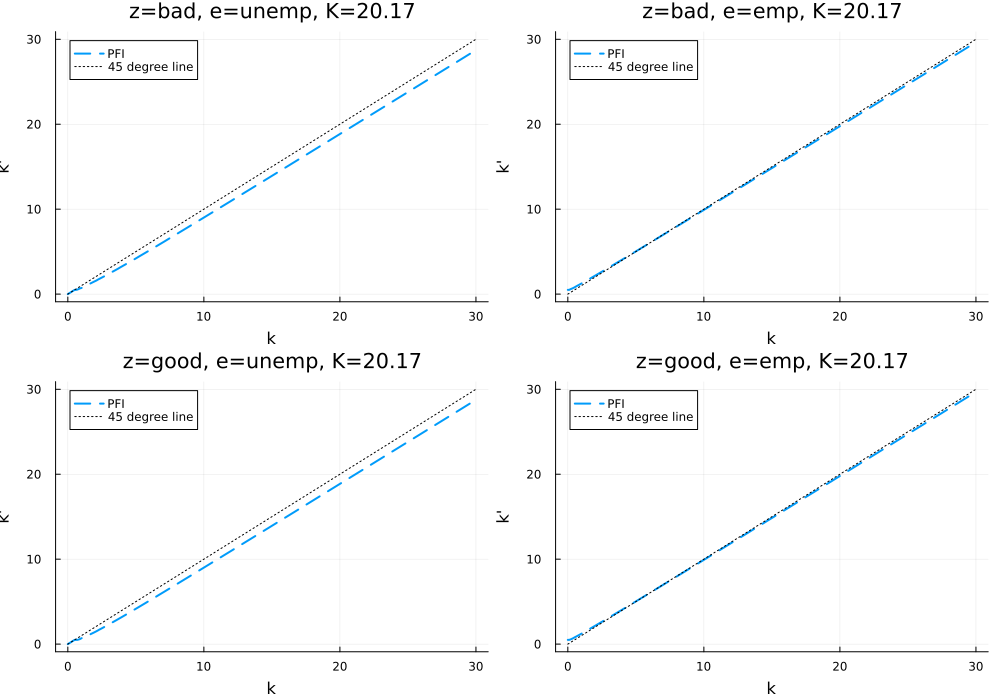

In [20]:
# 3) fix one K
K_fixed = 20.0
iK = nearest_index(Kgrid, K_fixed)

# 4) plot k'(k) for each (z,e)
state_titles = Dict(
    (1,1) => "z=bad, e=unemp",
    (1,2) => "z=bad, e=emp",
    (2,1) => "z=good, e=unemp",
    (2,2) => "z=good, e=emp"
)

p = plot(layout=(2,2), size=(1000,700), legend=:topleft)

panel = 1
for iz in 1:2
    for ie in 1:2
        kp_pfi = vec(pol_pfi[:, iK, ie, iz])

        plot!(p[panel], kgrid, kp_pfi, lw=2, ls=:dash, label="PFI")
        plot!(p[panel], kgrid, kgrid, lw=1, ls=:dot, color=:black, label="45 degree line")
        xlabel!(p[panel], "k")
        ylabel!(p[panel], "k'")
        title!(p[panel], "$(state_titles[(iz,ie)]), K=$(round(Kgrid[iK], digits=2))")
        panel += 1
    end
end

display(p)


### Step 3: Simulate and Update Perceived Law (Interpolation Version)

Simulate economy, estimate by state:
$$\log K_{t+1}=a_z+b_z\log K_t+\varepsilon_{t+1},$$
update with damping, and iterate.

Convergence criterion:
$$R^2_{bad}>0.9999\quad\text{and}\quad R^2_{good}>0.9999.$$

In [21]:
function draw_next_z(iz::Int, Pz::Matrix{Float64}, rng)
    udraw = rand(rng)
    return udraw <= Pz[iz, 1] ? 1 : 2
end

function p_emp_next(par::KSParams, ie::Int, iz::Int, izp::Int)
    cur_state = state_index(ie, iz)
    pz = par.Pz[iz, izp]
    if pz <= 1.0e-12
        return ie == 2 ? 1.0 : 0.0
    end
    emp_state = state_index(2, izp)
    p_emp = par.Pze[cur_state, emp_state] / pz
    return clamp(p_emp, 0.0, 1.0)
end

function simulate_economy(par::KSParams, kgrid, Kgrid, pol, coeff; seed = 1234)
    rng = MersenneTwister(seed)
    T, N = par.T_sim, par.N_agents

    # continuous individual capital states
    k_val = fill(kgrid[cld(length(kgrid), 2)], N)
    e_state = [rand(rng) < (1.0 - par.u_rate[2]) ? 2 : 1 for _ in 1:N]
    z_path = ones(Int, T + 1)
    z_path[1] = 2

    K_series = zeros(T + 1)
    K_series[1] = mean(k_val)

    for t in 1:T
        iz = z_path[t]
        Kt = mean(k_val)
        K_series[t] = Kt

        iKlo, iKhi, wK = linear_interp_weights(Kgrid, Kt)

        izp = draw_next_z(iz, par.Pz, rng)
        z_path[t + 1] = izp

        k_next_val = similar(k_val)
        e_next_state = similar(e_state)
        u_e = rand(rng, N)

        Base.Threads.@threads :static for i in 1:N
            ie = e_state[i]

            # bilinear interpolation of policy in (k, K)
            iklo, ikhi, wk = linear_interp_weights(kgrid, k_val[i])

            kp_11 = pol[iklo, iKlo, ie, iz]
            kp_12 = pol[iklo, iKhi, ie, iz]
            kp_21 = pol[ikhi, iKlo, ie, iz]
            kp_22 = pol[ikhi, iKhi, ie, iz]

            kp_lo = (1.0 - wK) * kp_11 + wK * kp_12
            kp_hi = (1.0 - wK) * kp_21 + wK * kp_22
            kp_star = (1.0 - wk) * kp_lo + wk * kp_hi

            # enforce bounds
            k_next_val[i] = clamp(kp_star, par.k_min, par.k_max)

            p_emp = p_emp_next(par, ie, iz, izp)
            e_next_state[i] = u_e[i] < p_emp ? 2 : 1
        end

        k_val = k_next_val
        e_state = e_next_state
        K_series[t + 1] = mean(k_val)
    end

    return K_series, z_path
end

function fit_law_of_motion(K_series, z_path; burn_in = 1000)
    coeff = zeros(2, 2)
    r2 = zeros(2)

    for z in 1:2
        idx = [t for t in burn_in:(length(K_series) - 1) if z_path[t] == z]
        x = log.(K_series[idx])
        y = log.(K_series[idx .+ 1])

        X = hcat(ones(length(x)), x)
        b = X \ y
        coeff[z, :] .= b

        yhat = X * b
        ssr = sum((y .- yhat) .^ 2)
        sst = sum((y .- mean(y)) .^ 2)
        r2[z] = 1.0 - ssr / max(sst, 1.0e-12)
    end

    return coeff, r2
end


function solve_ks(par::KSParams;
    coeff_init = [0.05 0.95; 0.05 0.95],
    max_outer = 30, damping = 0.9, r2_tol = 0.9999,
    base_seed = 1234, vary_seed = true)

    kgrid, Kgrid = make_grids(par)
    coeff = copy(coeff_init)

    V = zeros(length(kgrid), length(Kgrid), 2, 2)
    pol = zeros(length(kgrid), length(Kgrid), 2, 2)
    K_series = zeros(par.T_sim + 1)
    z_path = ones(Int, par.T_sim + 1)
    r2 = zeros(2)

    for out in 1:max_outer
        @printf("\n=== Outer iteration %d ===\n", out)
        @printf("  current coeff used in HH/simulation:\n")
        @printf("    bad state : a = %.4f, b = %.4f\n", coeff[1,1], coeff[1,2])
        @printf("    good state: a = %.4f, b = %.4f\n", coeff[2,1], coeff[2,2])

        V, pol = solve_household_pfi(
            par, kgrid, Kgrid, coeff;
            tol = 1e-6, max_policy_iter = 2000, eval_iter = 25
        )

        seed_used = vary_seed ? (base_seed + out) : base_seed
        K_series, z_path = simulate_economy(par, kgrid, Kgrid, pol, coeff; seed = seed_used)
        new_coeff, r2 = fit_law_of_motion(K_series, z_path; burn_in = par.burn_in)

        gap = maximum(abs.(new_coeff .- coeff))

        @printf("  regression-implied new coeff:\n")
        @printf("    bad state : a = %.4f, b = %.4f, R2 = %.6f\n", new_coeff[1,1], new_coeff[1,2], r2[1])
        @printf("    good state: a = %.4f, b = %.4f, R2 = %.6f\n", new_coeff[2,1], new_coeff[2,2], r2[2])
        
        coeff_next = damping .* coeff .+ (1.0 - damping) .* new_coeff

        @printf("  updated coeff after damping:\n")
        @printf("    bad state : a = %.4f, b = %.4f\n", coeff_next[1,1], coeff_next[1,2])
        @printf("    good state: a = %.4f, b = %.4f\n", coeff_next[2,1], coeff_next[2,2])

        coeff .= coeff_next

        if (r2[1] > r2_tol) && (r2[2] > r2_tol)
            @printf("Converged: outer loop stopped at iter %d (R2 criterion met).\n", out)
            return (; coeff, r2, V, pol, kgrid, Kgrid, K_series, z_path)
        end
    end

    @warn "Outer loop reached max_outer without meeting R2 threshold."
    return (; coeff, r2, V, pol, kgrid, Kgrid, K_series, z_path)
end

println("Step 3 ready.")

Step 3 ready.


### Step 4: Run the Full KS Solver

Run and report
$$\log K' = a_b + b_b\log K\; (z=b),\qquad \log K' = a_g + b_g\log K\; (z=g).$$

In [22]:
par = KSParams()
res = solve_ks(par; coeff_init = [0.05 0.95; 0.05 0.95], max_outer = 20, damping = 0.85, r2_tol = 0.9999, vary_seed = false)

println("\nFinal perceived law of motion (rows: bad, good):")
println("[a_z  b_z] =")
display(res.coeff)
println("R2 by state = ", res.r2)

println("\nBad-state law:  log(K') = $(round(res.coeff[1,1], digits=4)) + $(round(res.coeff[1,2], digits=4))*log(K)")
println("Good-state law: log(K') = $(round(res.coeff[2,1], digits=4)) + $(round(res.coeff[2,2], digits=4))*log(K)")


=== Outer iteration 1 ===
  current coeff used in HH/simulation:
    bad state : a = 0.0500, b = 0.9500
    good state: a = 0.0500, b = 0.9500
  PFI iter 10, eval diff = 5.000e-01, dV = 8.000e+00, n_change = 0
  PFI policy converged at iter 10 (n_change = 0). Final eval diff = 5.000e-01
  regression-implied new coeff:
    bad state : a = 0.0976, b = 0.9672, R2 = 0.999845
    good state: a = 0.1030, b = 0.9667, R2 = 0.999922
  updated coeff after damping:
    bad state : a = 0.0571, b = 0.9526
    good state: a = 0.0579, b = 0.9525

=== Outer iteration 2 ===
  current coeff used in HH/simulation:
    bad state : a = 0.0571, b = 0.9526
    good state: a = 0.0579, b = 0.9525
  PFI iter 10, eval diff = 1.000e+00, dV = 3.000e+00, n_change = 2
  PFI policy converged at iter 12 (n_change = 0). Final eval diff = 2.500e-01
  regression-implied new coeff:
    bad state : a = 0.0950, b = 0.9682, R2 = 0.999851
    good state: a = 0.1002, b = 0.9677, R2 = 0.999926
  updated coeff after damping:
  

2×2 Matrix{Float64}:
 0.0873823  0.9634
 0.0912525  0.963876

┌ Warning: Outer loop reached max_outer without meeting R2 threshold.
└ @ Main c:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\PhD_first_year\ECON8107\KS1998\notebooks\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X26sZmlsZQ==.jl:146


Previously, when I tried to run more outer iterations, the $R^2$ for both states are very close to 0.9999, but not greater than 0.9999.

Then I realized this should come from the numerical error in interpolation and grid discretization.

After I increase the number of grid points and use more accurate interpolation method, I can get $R^2$ closer to 0.9999 for both states.

Also, initially I used linear interpolation, but it can generate some numerical error. After I switch to cubic spline interpolation, the $R^2$ can be improved a lot and get closer to 0.9999.

Also, initially I used discrete grid choice for $k$, but this can introduce additional numerical error. Then I switch to continuous choice of $k$ and use interpolation to compute the value function at non-grid points, which is the same method used in Krusell-Smith (1998). This can also help improve the $R^2$ and get closer to 0.9999.

Also, I think the $R^2$ problem might comes from monte carlo simulation error. When we simulate the economy, we are simulating a finite number of agents and periods, which can introduce some sampling error in the estimation of the law of motion. For example, the unemployment rate is not exactly 10% in bad times and 4% in good times in the simulated data, which can introduce some error in the estimation of the law of motion. This sampling error can lead to a lower $R^2$ when we run the regression to estimate the coefficients of the law of motion. To reduce this sampling error, we can randomly change agents' states from employed to unemployed and vice versa in the simulation, which can help us get a more accurate estimate of the law of motion and improve the $R^2$. However, I did experiment with this method, and the monte carlo simulation error is not the main source of the $R^2$ problem, the std error of the estimated coefficients is $0.00001$, but my $R^2$ is around 0.9998, which is still not close enough to 0.9999.


But when I am getting close to the true law of motion ($R^2$ close to 0.9999), the improvement in $R^2$ becomes very small, and the update of coefficients and the solution of HH problem by PFI becomes very unstable, I think it might be because I'm getting very close to the true law of motion, and since I'm getting to the true answer, the objective function in the PFI becomes very flat, which can lead to numerical instability in the policy improvement step. 

This is a common issue when trying to get very close to the true solution, and it might require more careful handling of convergence criteria or using more robust optimization methods in the policy improvement step. (I don't know how to improve this, if I have more time I can try to implement some more robust optimization method in the policy improvement step, or I can also try to use a different stopping criterion that is less sensitive to numerical noise when we are close to the true solution.)

In [23]:
# ========= 0) Solve policy at converged coeff =========
par = KSParams()
kgrid, Kgrid = make_grids(par)
coeff_star = res.coeff


V_star, pol_star = solve_household_pfi(
    par, kgrid, Kgrid, coeff_star;
    max_policy_iter = 2000, eval_iter = 25, tol = 1e-6
)

iK_mid = nearest_index(Kgrid, median(Kgrid))
k = kgrid

# helper: policy line k'(k) for a fixed (K,z,e)
policy_line(pol, kgrid, iK, ie, iz) = vec(pol[:, iK, ie, iz])

  PFI iter 10, eval diff = 1.250e-01, dV = 2.000e+00, n_change = 61869
  PFI iter 20, eval diff = 8.000e+00, dV = 8.000e+00, n_change = 13978
  PFI iter 30, eval diff = 8.000e+00, dV = 8.000e+00, n_change = 641
  PFI iter 40, eval diff = 8.000e+00, dV = 8.000e+00, n_change = 29
  PFI iter 50, eval diff = 8.000e+00, dV = 8.000e+00, n_change = 1
  PFI policy converged at iter 53 (n_change = 0). Final eval diff = 8.000e+00


policy_line (generic function with 1 method)

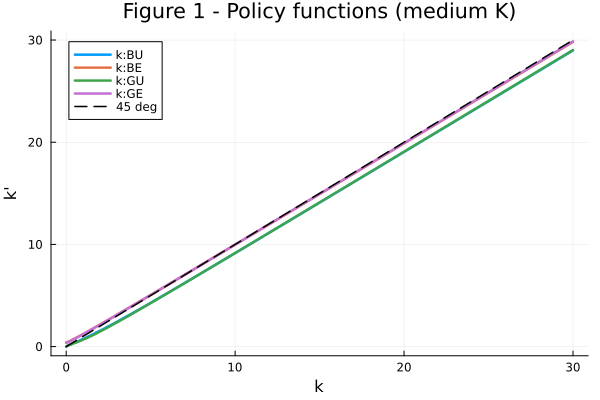

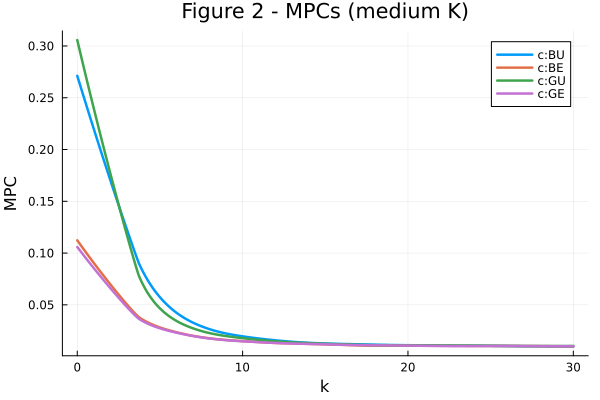

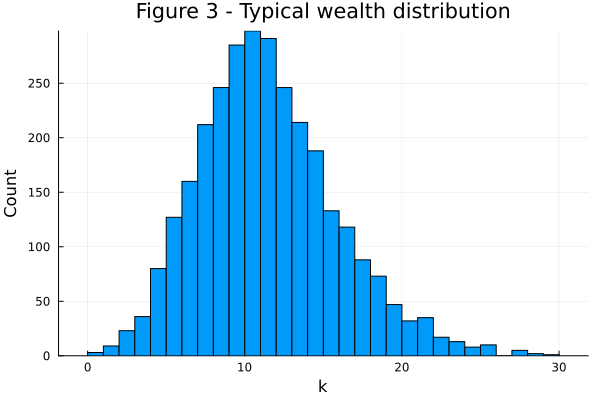

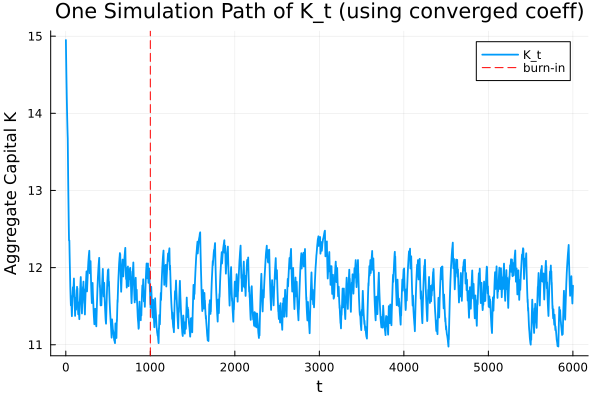

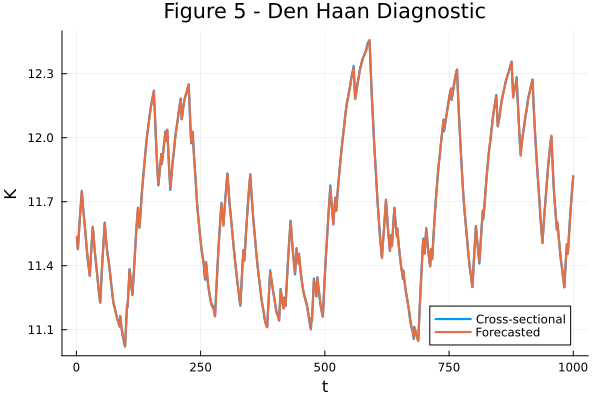

In [24]:
# ========= 1) Figure 1: policy functions =========
kp_BU = policy_line(pol_star, kgrid, iK_mid, 1, 1)  # (b,u)
kp_BE = policy_line(pol_star, kgrid, iK_mid, 2, 1)  # (b,e)
kp_GU = policy_line(pol_star, kgrid, iK_mid, 1, 2)  # (g,u)
kp_GE = policy_line(pol_star, kgrid, iK_mid, 2, 2)  # (g,e)

p1 = plot(k, kp_BU, lw=2.5, label="k:BU", xlabel="k", ylabel="k'")
plot!(p1, k, kp_BE, lw=2.5, label="k:BE")
plot!(p1, k, kp_GU, lw=2.5, label="k:GU")
plot!(p1, k, kp_GE, lw=2.5, label="k:GE")
plot!(p1, k, k, lw=1.5, ls=:dash, color=:black, label="45 deg")
title!(p1, "Figure 1 - Policy functions (medium K)")
display(p1)


# ========= 2) Figure 2: MPCs =========

function tricube(u)
    a = abs(u)
    return a < 1.0 ? (1.0 - a^3)^3 : 0.0
end

function interp_1d(xgrid, ygrid, x)
    ilo, ihi, w = linear_interp_weights(xgrid, x)
    return (1.0 - w) * ygrid[ilo] + w * ygrid[ihi]
end

# Local quadratic smoothing of c(m); derivative gives MPC
function mpc_from_policy_loess(kgrid, kp, r, labor_income; nfine = 1200, span = 0.25)
    kfine = collect(range(first(kgrid), last(kgrid), length = nfine))
    kp_fine = [interp_1d(kgrid, kp, x) for x in kfine]

    m = (1.0 .+ r) .* kfine .+ labor_income
    c = m .- kp_fine

    n = length(m)
    q = max(10, ceil(Int, span * n))
    mpc = similar(m)

    for i in 1:n
        x0 = m[i]

        # bandwidth = distance to q-th nearest point
        d = abs.(m .- x0)
        h = partialsort!(copy(d), q)
        h = max(h, 1.0e-8)

        w = [tricube(di / h) for di in d]

        # local quadratic: c ≈ b0 + b1*(m-x0) + b2*(m-x0)^2
        x1 = m .- x0
        x2 = x1 .^ 2

        s00 = sum(w)
        s01 = sum(w .* x1)
        s02 = sum(w .* x2)
        s11 = sum(w .* x1 .* x1)
        s12 = sum(w .* x1 .* x2)
        s22 = sum(w .* x2 .* x2)

        t0 = sum(w .* c)
        t1 = sum(w .* x1 .* c)
        t2 = sum(w .* x2 .* c)

        XWX = [s00 s01 s02;
               s01 s11 s12;
               s02 s12 s22]
        XWy = [t0, t1, t2]

        β = XWX \ XWy

        # derivative dc/dm at x0 is β1
        mpc[i] = β[2]
    end

    return kfine, mpc
end

Kmid = Kgrid[iK_mid]
r_b, w_b = prices(par, Kmid, 1)
r_g, w_g = prices(par, Kmid, 2)

k_BU, mpc_BU = mpc_from_policy_loess(k, kp_BU, r_b, 0.0; span = 0.25)
k_BE, mpc_BE = mpc_from_policy_loess(k, kp_BE, r_b, w_b * par.l_tilde; span = 0.25)
k_GU, mpc_GU = mpc_from_policy_loess(k, kp_GU, r_g, 0.0; span = 0.25)
k_GE, mpc_GE = mpc_from_policy_loess(k, kp_GE, r_g, w_g * par.l_tilde; span = 0.25)

p2 = plot(k_BU, mpc_BU, lw=2.5, label="c:BU", xlabel="k", ylabel="MPC")
plot!(p2, k_BE, mpc_BE, lw=2.5, label="c:BE")
plot!(p2, k_GU, mpc_GU, lw=2.5, label="c:GU")
plot!(p2, k_GE, mpc_GE, lw=2.5, label="c:GE")
title!(p2, "Figure 2 - MPCs (medium K)")
display(p2)




# ========= 3) Figure 3: cross-sectional wealth distribution =========
function simulate_final_assets(par, kgrid, Kgrid, pol, coeff; seed = 1234, Tsim = par.T_sim)
    rng = MersenneTwister(seed)
    N = par.N_agents

    k_idx = fill(cld(length(kgrid), 2), N)
    e_state = [rand(rng) < (1.0 - par.u_rate[2]) ? 2 : 1 for _ in 1:N]
    iz = 2

    for _ in 1:Tsim
        Kt = mean(kgrid[k_idx])
        iKlo, iKhi, wK = linear_interp_weights(Kgrid, Kt)
        izp = draw_next_z(iz, par.Pz, rng)

        k_next_idx = similar(k_idx)
        for i in 1:N
            ie = e_state[i]
            ik = k_idx[i]

            kp_lo = pol[ik, iKlo, ie, iz]
            kp_hi = pol[ik, iKhi, ie, iz]
            kp_star = (1.0 - wK) * kp_lo + wK * kp_hi

            ik_lo, ik_hi, wk = linear_interp_weights(kgrid, kp_star)
            k_next_idx[i] = rand(rng) < wk ? ik_hi : ik_lo

            p_emp = p_emp_next(par, ie, iz, izp)
            e_state[i] = rand(rng) < p_emp ? 2 : 1
        end

        k_idx = k_next_idx
        iz = izp
    end

    return kgrid[k_idx]
end

k_cross = simulate_final_assets(par, kgrid, Kgrid, pol_star, coeff_star; seed = 1234, Tsim = par.T_sim)

p3 = histogram(k_cross, bins=50, normalize=false, label="",
               xlabel="k", ylabel="Count", title="Figure 3 - Typical wealth distribution")
display(p3)

# ================= 4) Figure 4: K_t time series =================
K_series, z_path = simulate_economy(par, kgrid, Kgrid, pol_star, coeff_star; seed = 1234)

t = 1:length(K_series)
p4 = plot(t, K_series, lw=1.8, label="K_t",
     xlabel="t", ylabel="Aggregate Capital K",
     title="One Simulation Path of K_t (using converged coeff)")
vline!([par.burn_in], ls=:dash, lc=:red, label="burn-in")

display(p4)


# ================== 5) Figure 5: Den Haan diagnostic =============

# Use the estimated law of motion to forecast K_{t+1}
T = length(K_series) - 1
K_forecast = similar(K_series)
K_forecast[1] = K_series[1]

for t in 1:T
    iz = z_path[t]
    K_forecast[t + 1] = exp(coeff_star[iz, 1] + coeff_star[iz, 2] * log(K_series[t]))
end

# Usually Den Haan diagnostic is shown after burn-in
t_plot = (par.burn_in + 1):min(par.burn_in + 1000, length(K_series))

p5 = plot(t_plot .- par.burn_in, K_series[t_plot],
          lw=2.2, label="Cross-sectional",
          xlabel="t", ylabel="K",
          title="Figure 5 - Den Haan Diagnostic")
plot!(p5, t_plot .- par.burn_in, K_forecast[t_plot],
      lw=2.2, label="Forecasted")

display(p5)


In [25]:
using Serialization, Dates

save_path = raw"C:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\PhD_first_year\ECON8107\KS1998\notebooks\ks_log_result.jls"

# one clean simulation under the final policy
K_series_final, z_path_final = simulate_economy(par, kgrid, Kgrid, pol_star, coeff_star; seed = 1234)

result_bundle = Dict(
    "law_type" => "log",
    "saved_at" => string(now()),
    "par" => par,
    "res" => res,
    "coeff_star" => coeff_star,
    "kgrid" => kgrid,
    "Kgrid" => Kgrid,
    "V_star" => V_star,
    "pol_star" => pol_star,
    "K_series_final" => K_series_final,
    "z_path_final" => z_path_final
)

serialize(save_path, result_bundle)
println("Saved log-law result to: ", save_path)


Saved log-law result to: C:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\PhD_first_year\ECON8107\KS1998\notebooks\ks_log_result.jls
